# Late Fusion Model with EEG Modality

This notebook implements late fusion combining **four modalities**:
- **Physiological data** (pupil metrics)
- **Behavioral data** (reaction time, decision time, etc.)
- **Gaze data** (gaze position, movements, fixations)
- **EEG data** (band power features across brain regions)

**Note**: 
- EEG data is available for **85 subjects** (82 overlap with extracted features)
- EEG data is from the **display/decision phase (PRE-decision period only)**
- This notebook should be run with `TIMEFRAME = 'PRE'`

Goals:
1. Load and merge EEG features with other modalities
2. Train separate models for each modality
3. Implement late fusion (average, weighted, stacking)
4. Extract weights to estimate modality influence on predictions
5. Compare performance with and without EEG

In [1]:
# ============================================================================
# CONFIGURATION
# ============================================================================
# EEG data is only available for PRE-decision period (display phase)
TIMEFRAME = 'PRE'  # Fixed to PRE - EEG is from display/decision phase
# ============================================================================

import sys
sys.path.append('../..')  # Add project root to path

import json
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal
import warnings
warnings.filterwarnings('ignore')

# Import from src package
from src.utils.io import load_features, save_results
from src.utils.config import get_model_params, load_config
from src.utils.validation import validate_features, validate_modality_features
from src.models.fusion import weighted_late_fusion
from src.visualization.plots import (
    plot_method_comparison,
    plot_modality_weights,
    set_style
)

np.random.seed(42)
set_style('whitegrid')  # Use shared style function

print(f"\n{'='*70}")
print(f"LATE FUSION WITH EEG: {TIMEFRAME}-DECISION PERIOD")
print(f"Note: EEG data is from display/decision phase (PRE only)")
print(f"{'='*70}\n")


LATE FUSION WITH EEG: PRE-DECISION PERIOD
Note: EEG data is from display/decision phase (PRE only)



## 1. Load Pre-Extracted Features (All Modalities)

In [2]:
# Load configuration
config = load_config('model_params')
time_window = config['time_windows'][f'{TIMEFRAME.lower()}_decision']

print(f"Time window: {time_window['start']}s to {time_window['end']}s")
print(f"Description: {time_window['description']}\n")

# Load pre-extracted features (physio, behavior, gaze)
features_path = f'../../data/features/extracted_features_{TIMEFRAME}.pkl'
feature_data = load_features(features_path, timeframe=TIMEFRAME)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

print(f"Loaded {len(merged_df)} trials from {merged_df['subject_id'].nunique()} subjects")
print(f"\nFeature counts:")
print(f"  Physiology ({TIMEFRAME}): {len(physio_cols)} features")
print(f"  Behavior: {len(behavior_cols)} features")
print(f"  Gaze: {len(gaze_cols)} features")

Time window: -2.0s to 0.0s
Description: Anticipatory period before submit button

Loaded 12511 trials from 97 subjects

Feature counts:
  Physiology (PRE): 13 features
  Behavior: 7 features
  Gaze: 20 features


## 2. Load and Extract EEG Features

In [ ]:
# EEG feature extraction parameters (Gamma excluded due to noise)
freq_bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
}

# Channel names matching chan_locs.sfp (10-20 system, 20 channels)
# Order matches the sfp file for electrode position mapping
channel_names = [
    'Fp1', 'F7', 'F8', 'T4', 'T6', 'T5', 'T3', 'Fp2', 'O1', 'P3',
    'Pz', 'F3', 'Fz', 'F4', 'C4', 'P4', 'POz', 'C3', 'Cz', 'O2'
]

# Channel regions for grouped analysis
channel_regions = {
    'Frontal': ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8'],
    'Central': ['T3', 'C3', 'Cz', 'C4', 'T4'],
    'Parietal': ['T5', 'P3', 'Pz', 'P4', 'T6'],
    'Occipital': ['O1', 'POz', 'O2']
}

def compute_band_power(eeg_data, fs=256, bands=None):
    """Compute band power for each channel and frequency band.
    
    Parameters
    ----------
    eeg_data : np.ndarray
        EEG data with shape (n_channels, n_timepoints)
    fs : int
        Sampling frequency in Hz
    bands : dict
        Frequency bands to compute power for
    
    Returns
    -------
    dict
        Band powers for each frequency band
    """
    if bands is None:
        bands = freq_bands
    
    freqs, psd = signal.welch(eeg_data, fs=fs, nperseg=min(256, eeg_data.shape[1]))
    
    band_powers = {}
    for band_name, (f_low, f_high) in bands.items():
        freq_mask = (freqs >= f_low) & (freqs <= f_high)
        band_power = np.trapz(psd[:, freq_mask], freqs[freq_mask], axis=1)
        band_powers[band_name] = band_power
    
    return band_powers

def extract_eeg_features(eeg_df, fs=256):
    """Extract band power features for all trials.
    
    The new EEG file has display_eeg with shape (time, channels).
    We transpose to (channels, time) for processing.
    """
    features_list = []
    
    for idx, row in eeg_df.iterrows():
        # display_eeg has shape (320, 20) = (time, channels)
        # Transpose to (20, 320) = (channels, time) for band power computation
        display_eeg = np.array(row['display_eeg']).T  # Now (channels, time)
        
        # Compute band powers
        bp = compute_band_power(display_eeg, fs)
        
        # Create composite trial_id to match extracted_features format
        trial_features = {
            'subject_id': row['subject_date_id'],
            'trial_id': f"{row['trial_id']}_{row['subject_date_id']}"
        }
        
        for band_name in freq_bands.keys():
            band_power = bp[band_name]
            
            # Average by region
            for region, channels in channel_regions.items():
                ch_indices = [channel_names.index(ch) for ch in channels]
                avg_power = np.mean(band_power[ch_indices])
                trial_features[f'eeg_{band_name}_{region}'] = avg_power
        
        features_list.append(trial_features)
    
    return pd.DataFrame(features_list)

# Load preprocessed EEG data (85 subjects)
eeg_file = '../../data/eeg/Copy of preprocessed_eeg.pkl'
print(f"Loading EEG data from: {eeg_file}")
with open(eeg_file, 'rb') as f:
    eeg_raw_df = pickle.load(f)

print(f"Loaded {len(eeg_raw_df)} EEG trials from {eeg_raw_df['subject_date_id'].nunique()} subjects")

# Check array shape
sample_arr = np.array(eeg_raw_df['display_eeg'].iloc[0])
print(f"EEG array shape: {sample_arr.shape} (time x channels)")

# Extract EEG features
print("\nExtracting EEG features from display_eeg...")
eeg_features_df = extract_eeg_features(eeg_raw_df, fs=256)
eeg_cols = [c for c in eeg_features_df.columns if c.startswith('eeg_')]

print(f"Extracted {len(eeg_cols)} EEG features")

Loading EEG data from: ../../data/eeg/Copy of preprocessed_eeg.pkl
Loaded 10855 EEG trials from 85 subjects
EEG array shape: (320, 20) (time x channels)

Extracting EEG features from display_eeg...
Extracted 16 EEG features
EEG subjects (85): showing first 10...
['0831_1300_9M4VCHG' '0811_1000_U9TEJGM' '0831_1300_539136F'
 '0825_1300_9M4VCHG' '0923_1000_U9TEJGM' '0824_1000_U9TEJGM'
 '0920_1600_U9TEJGM' '0818_1600_539136F' '0818_1600_9M4VCHG'
 '0924_1600_U9TEJGM']


## 3. Merge Features and Filter to EEG Subjects

In [4]:
# Get EEG subjects
eeg_subjects = eeg_features_df['subject_id'].unique()
print(f"EEG subjects ({len(eeg_subjects)}): {eeg_subjects}")

# Filter merged_df to only EEG subjects
merged_df_eeg = merged_df[merged_df['subject_id'].isin(eeg_subjects)].copy()
print(f"\nFiltered to EEG subjects: {len(merged_df_eeg)} trials")

# Merge with EEG features on trial_id
merged_df_eeg = merged_df_eeg.merge(
    eeg_features_df[['trial_id'] + eeg_cols],
    on='trial_id',
    how='inner'
)

print(f"After merging with EEG: {len(merged_df_eeg)} trials")
print(f"Subjects: {merged_df_eeg['subject_id'].nunique()}")
print(f"Trials per subject: {merged_df_eeg.groupby('subject_id').size().to_dict()}")

# Check outcome balance
outcome_counts = merged_df_eeg['outcome'].value_counts()
print(f"\nOutcome balance: {outcome_counts.get(0, 0)} keep / {outcome_counts.get(1, 0)} invest")

EEG subjects (85): ['0831_1300_9M4VCHG' '0811_1000_U9TEJGM' '0831_1300_539136F'
 '0825_1300_9M4VCHG' '0923_1000_U9TEJGM' '0824_1000_U9TEJGM'
 '0920_1600_U9TEJGM' '0818_1600_539136F' '0818_1600_9M4VCHG'
 '0924_1600_U9TEJGM' '0922_1000_539136F' '0922_1000_9M4VCHG'
 '0830_1300_U9TEJGM' '0831_1000_9M4VCHG' '0830_1300_9M4VCHG'
 '0830_1300_539136F' '0802_1400_A6I5HI6' '0818_1600_U9TEJGM'
 '0922_1000_U9TEJGM' '0924_1600_539136F' '0924_1600_9M4VCHG'
 '0824_1000_9M4VCHG' '0923_1000_539136F' '0824_1000_539136F'
 '0923_1000_9M4VCHG' '0920_1600_9M4VCHG' '0920_1600_539136F'
 '0831_1300_U9TEJGM' '0924_1000_539136F' '0924_1000_9M4VCHG'
 '1005_1600_U9TEJGM' '0901_1300_9M4VCHG' '0901_1300_539136F'
 '0823_1400_539136F' '0823_1400_9M4VCHG' '0917_1030_U9TEJGM'
 '0813_1000_U9TEJGM' '0816_1400_539136F' '0927_0930_U9TEJGM'
 '0816_1400_9M4VCHG' '0731_1000_U9TEJGM' '0930_1700_9M4VCHG'
 '0930_1700_539136F' '0828_1300_9M4VCHG' '0817_1000_U9TEJGM'
 '0928_1600_539136F' '0928_1600_9M4VCHG' '0915_1000_9M4VCHG'
 '091

## 4. Prepare Feature Sets

In [5]:
# Prepare feature arrays for model training
X_physio = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[physio_cols])
X_behavior = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[behavior_cols])

# Handle gaze features (may be limited in POST)
if len(gaze_cols) > 0:
    X_gaze = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[gaze_cols])
else:
    # Create placeholder array (no gaze data)
    X_gaze = np.zeros((len(merged_df_eeg), 1))

# EEG features
X_eeg = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[eeg_cols])

y = merged_df_eeg['outcome'].values
subjects = merged_df_eeg['subject_id'].values

print(f"Shapes:")
print(f"  X_physio:   {X_physio.shape}")
print(f"  X_behavior: {X_behavior.shape}")
print(f"  X_gaze:     {X_gaze.shape}")
print(f"  X_eeg:      {X_eeg.shape}")
print(f"  y:          {y.shape}")

Shapes:
  X_physio:   (10431, 13)
  X_behavior: (10431, 7)
  X_gaze:     (10431, 20)
  X_eeg:      (10431, 16)
  y:          (10431,)


In [6]:
def train_evaluate_modality(X, y, subjects, modality_name):
    """
    Train and evaluate a single modality using LOSO cross-validation.
    
    Parameters
    ----------
    X : np.ndarray
        Feature matrix for the modality
    y : np.ndarray
        Target labels
    subjects : np.ndarray
        Subject IDs for each sample
    modality_name : str
        Name of the modality
    
    Returns
    -------
    tuple
        (model, accuracy, f1_score, predictions, y_true)
    """
    logo = LeaveOneGroupOut()
    
    # Get model parameters from config
    model_params = get_model_params('random_forest')
    
    # Initialize storage
    all_preds = []
    all_y_true = []
    subject_accs = []
    subject_f1s = []
    
    print(f"\n{'='*50}")
    print(f"{modality_name} Model")
    print(f"{'='*50}")
    
    # LOSO cross-validation
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Train model
        model = RandomForestClassifier(**model_params)
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Store results
        all_preds.extend(y_pred)
        all_y_true.extend(y_test)
        
        # Subject-level metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        subject_accs.append(acc)
        subject_f1s.append(f1)
    
    # Calculate overall metrics
    overall_acc = np.mean(subject_accs)
    overall_f1 = np.mean(subject_f1s)
    
    print(f"Accuracy: {overall_acc:.3f} +/- {stats.sem(subject_accs):.3f}")
    print(f"F1-Score: {overall_f1:.3f} +/- {stats.sem(subject_f1s):.3f}")
    print(f"N subjects: {len(subject_accs)}")
    
    return model, overall_acc, overall_f1, np.array(all_preds), np.array(all_y_true)

## 5. Train Individual Modality Models

In [7]:
model_physio, acc_physio, f1_physio, pred_physio, y_true = train_evaluate_modality(
    X_physio, y, subjects, "Physiology"
)
model_behavior, acc_behavior, f1_behavior, pred_behavior, _ = train_evaluate_modality(
    X_behavior, y, subjects, "Behavior"
)

# Only train gaze model if gaze data exists
if len(gaze_cols) > 0:
    model_gaze, acc_gaze, f1_gaze, pred_gaze, _ = train_evaluate_modality(
        X_gaze, y, subjects, "Gaze"
    )
else:
    # Placeholder for POST (no gaze data)
    model_gaze = None
    acc_gaze = 0.5
    f1_gaze = 0.5
    pred_gaze = np.zeros(len(y))
    print(f"\n{'='*50}\nGaze Model\n{'='*50}")
    print("Skipping - no gaze data available (POST condition)")

# Train EEG model
model_eeg, acc_eeg, f1_eeg, pred_eeg, _ = train_evaluate_modality(
    X_eeg, y, subjects, "EEG"
)


Physiology Model
Accuracy: 0.518 +/- 0.015
F1-Score: 0.508 +/- 0.019
N subjects: 82

Behavior Model
Accuracy: 0.649 +/- 0.014
F1-Score: 0.666 +/- 0.015
N subjects: 82

Gaze Model
Accuracy: 0.519 +/- 0.013
F1-Score: 0.524 +/- 0.015
N subjects: 82

EEG Model
Accuracy: 0.517 +/- 0.016
F1-Score: 0.498 +/- 0.017
N subjects: 82


## 6. Late Fusion Implementation

Using shared `weighted_late_fusion` function from `src.models.fusion` with 4 modalities.

In [8]:
# Run fusion methods with all 4 modalities
if len(gaze_cols) > 0:
    X_modalities = [X_physio, X_behavior, X_gaze, X_eeg]
    modality_names = ['Physiology', 'Behavior', 'Gaze', 'EEG']
else:
    # POST condition: no gaze data
    X_modalities = [X_physio, X_behavior, X_eeg]
    modality_names = ['Physiology', 'Behavior', 'EEG']

# Validate modalities before fusion
validate_modality_features(X_modalities, y, subjects, modality_names)

print("\nRunning fusion methods with EEG...")
results_avg = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                   fusion_method='average')
results_weighted = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                        fusion_method='weighted')
results_stacking = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                        fusion_method='stacking')

✓ Modality validation passed:
  Physiology: 10431 samples × 13 features
  Behavior: 10431 samples × 7 features
  Gaze: 10431 samples × 20 features
  EEG: 10431 samples × 16 features

Running fusion methods with EEG...


## 7. Compare All Methods


PERFORMANCE COMPARISON (PRE) - WITH EEG (N=82 subjects)
         Method  Accuracy  F1-Score
Physiology Only  0.518251  0.507972
  Behavior Only  0.649384  0.665666
      Gaze Only  0.518603  0.523609
       EEG Only  0.516569  0.497793
 Average Fusion  0.649734  0.654558
Weighted Fusion  0.698044  0.684761
       Stacking  0.631058  0.644629


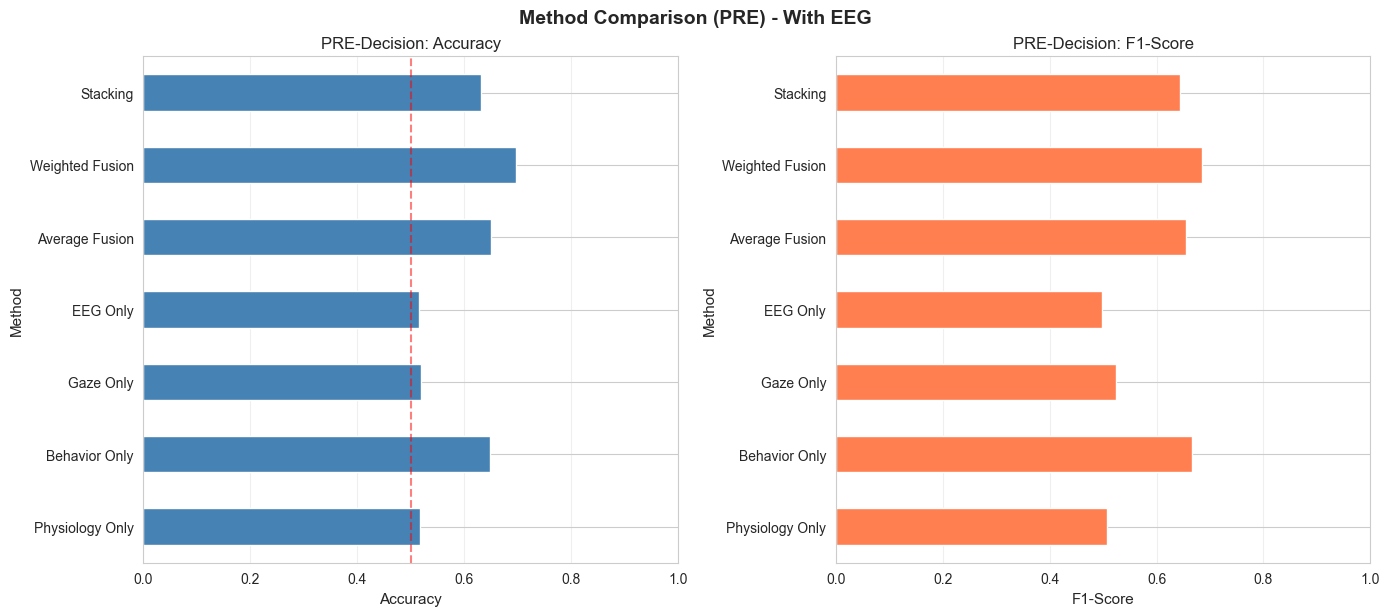

In [9]:
# Build comparison dataframe
comparison_data = {
    'Method': ['Physiology Only', 'Behavior Only'],
    'Accuracy': [acc_physio, acc_behavior],
    'F1-Score': [f1_physio, f1_behavior]
}

# Add gaze if available
if len(gaze_cols) > 0:
    comparison_data['Method'].append('Gaze Only')
    comparison_data['Accuracy'].append(acc_gaze)
    comparison_data['F1-Score'].append(f1_gaze)

# Add EEG
comparison_data['Method'].append('EEG Only')
comparison_data['Accuracy'].append(acc_eeg)
comparison_data['F1-Score'].append(f1_eeg)

# Add fusion methods
comparison_data['Method'].extend(['Average Fusion', 'Weighted Fusion', 'Stacking'])
comparison_data['Accuracy'].extend([
    results_avg['accuracy_mean'],
    results_weighted['accuracy_mean'],
    results_stacking['accuracy_mean']
])
comparison_data['F1-Score'].extend([
    results_avg['f1_mean'],
    results_weighted['f1_mean'],
    results_stacking['f1_mean']
])

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print(f"PERFORMANCE COMPARISON ({TIMEFRAME}) - WITH EEG (N={len(np.unique(subjects))} subjects)")
print("="*70)
print(comparison_df.to_string(index=False))

# Use shared plotting function
fig = plot_method_comparison(comparison_df, timeframe=TIMEFRAME)
plt.suptitle(f'Method Comparison ({TIMEFRAME}) - With EEG', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 8. Summary

In [10]:
print("\n" + "="*70)
print(f"SUMMARY ({TIMEFRAME}-DECISION) - WITH EEG")
print("="*70)

print(f"\n1. DATA SUMMARY:")
print(f"   N Subjects: {len(np.unique(subjects))}")
print(f"   N Trials:   {len(y)}")
print(f"   Outcome:    {(y==0).sum()} keep / {(y==1).sum()} invest")

print("\n2. INDIVIDUAL MODALITIES:")
print(f"   Physiology:  Acc={acc_physio:.3f}, F1={f1_physio:.3f}")
print(f"   Behavior:    Acc={acc_behavior:.3f}, F1={f1_behavior:.3f}")
if len(gaze_cols) > 0:
    print(f"   Gaze:        Acc={acc_gaze:.3f}, F1={f1_gaze:.3f}")
else:
    print(f"   Gaze:        Not available (POST condition)")
print(f"   EEG:         Acc={acc_eeg:.3f}, F1={f1_eeg:.3f}")

print("\n3. LATE FUSION METHODS:")
print(f"   Average:     Acc={results_avg['accuracy_mean']:.3f}, F1={results_avg['f1_mean']:.3f}")
print(f"   Weighted:    Acc={results_weighted['accuracy_mean']:.3f}, F1={results_weighted['f1_mean']:.3f}")
print(f"   Stacking:    Acc={results_stacking['accuracy_mean']:.3f}, F1={results_stacking['f1_mean']:.3f}")

print("\n4. MODALITY CONTRIBUTIONS (Weighted Fusion):")
for name, w in zip(modality_names, results_weighted['weights']):
    print(f"   {name:12s}: {w*100:5.1f}%")

best = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print(f"\n5. BEST METHOD: {best['Method']} (Acc={best['Accuracy']:.3f})")

print("\nNote: EEG data is from display/decision phase (PRE-decision period).")
print(f"      Analysis uses {len(np.unique(subjects))} subjects with EEG data.")
print("\n" + "="*70)


SUMMARY (PRE-DECISION) - WITH EEG

1. DATA SUMMARY:
   N Subjects: 82
   N Trials:   10431
   Outcome:    3550 keep / 6881 invest

2. INDIVIDUAL MODALITIES:
   Physiology:  Acc=0.518, F1=0.508
   Behavior:    Acc=0.649, F1=0.666
   Gaze:        Acc=0.519, F1=0.524
   EEG:         Acc=0.517, F1=0.498

3. LATE FUSION METHODS:
   Average:     Acc=0.650, F1=0.655
   Weighted:    Acc=0.698, F1=0.685
   Stacking:    Acc=0.631, F1=0.645

4. MODALITY CONTRIBUTIONS (Weighted Fusion):
   Physiology  :   2.5%
   Behavior    :  95.8%
   Gaze        :   0.6%
   EEG         :   1.1%

5. BEST METHOD: Weighted Fusion (Acc=0.698)

Note: EEG data is from display/decision phase (PRE-decision period).
      Analysis uses 82 subjects with EEG data.



## 9. Modality Weights Visualization


MODALITY WEIGHTS (Influence on Prediction)
  Modality  Average  Weighted  Stacking
Physiology     0.25  0.025435  0.119816
  Behavior     0.25  0.957662  0.825199
      Gaze     0.25  0.005644  0.030220
       EEG     0.25  0.011259  0.024765


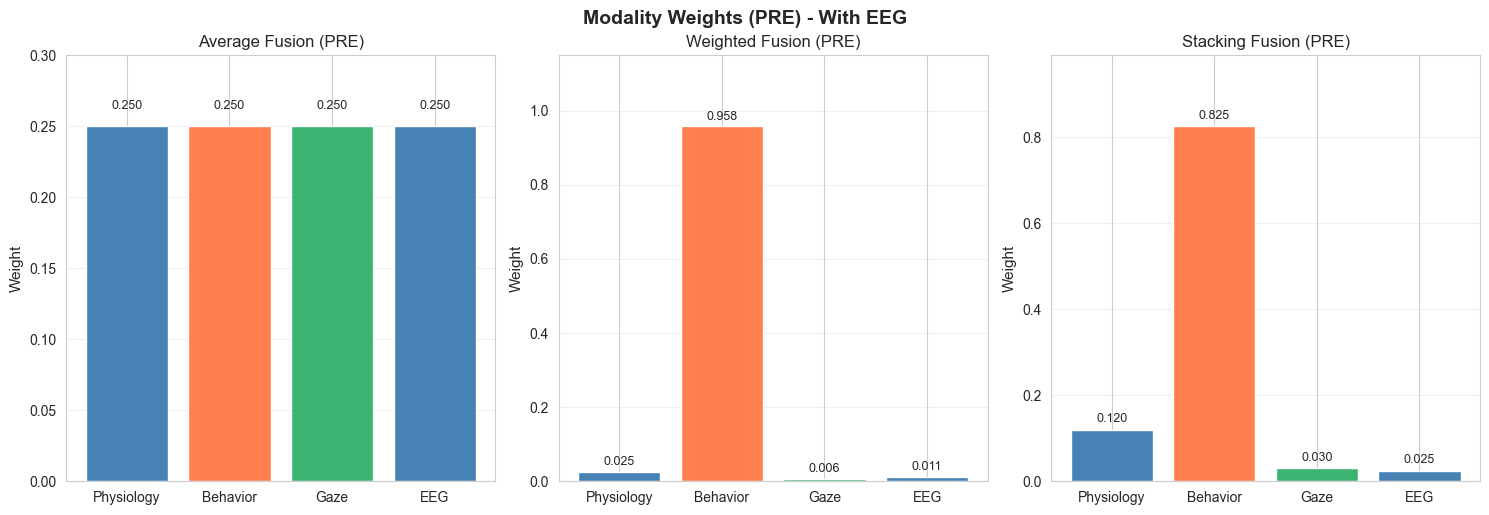

In [11]:
weights_df = pd.DataFrame({
    'Modality': modality_names,
    'Average': results_avg['weights'],
    'Weighted': results_weighted['weights'],
    'Stacking': results_stacking['weights']
})

print("\n" + "="*50)
print("MODALITY WEIGHTS (Influence on Prediction)")
print("="*50)
print(weights_df.to_string(index=False))

# Use shared plotting function
fig = plot_modality_weights(weights_df, timeframe=TIMEFRAME)
plt.suptitle(f'Modality Weights ({TIMEFRAME}) - With EEG', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 10. EEG Feature Importance


EEG FEATURE IMPORTANCES
            Feature  Importance
   eeg_Beta_Central    0.122236
   eeg_Beta_Frontal    0.089465
  eeg_Beta_Parietal    0.076664
 eeg_Beta_Occipital    0.070440
 eeg_Delta_Parietal    0.066201
eeg_Alpha_Occipital    0.064967
  eeg_Alpha_Frontal    0.064814
  eeg_Delta_Central    0.062813
  eeg_Theta_Frontal    0.056691
eeg_Delta_Occipital    0.052428
  eeg_Alpha_Central    0.050988
 eeg_Alpha_Parietal    0.046765
 eeg_Theta_Parietal    0.045148
  eeg_Theta_Central    0.044848
  eeg_Delta_Frontal    0.044830
eeg_Theta_Occipital    0.040702


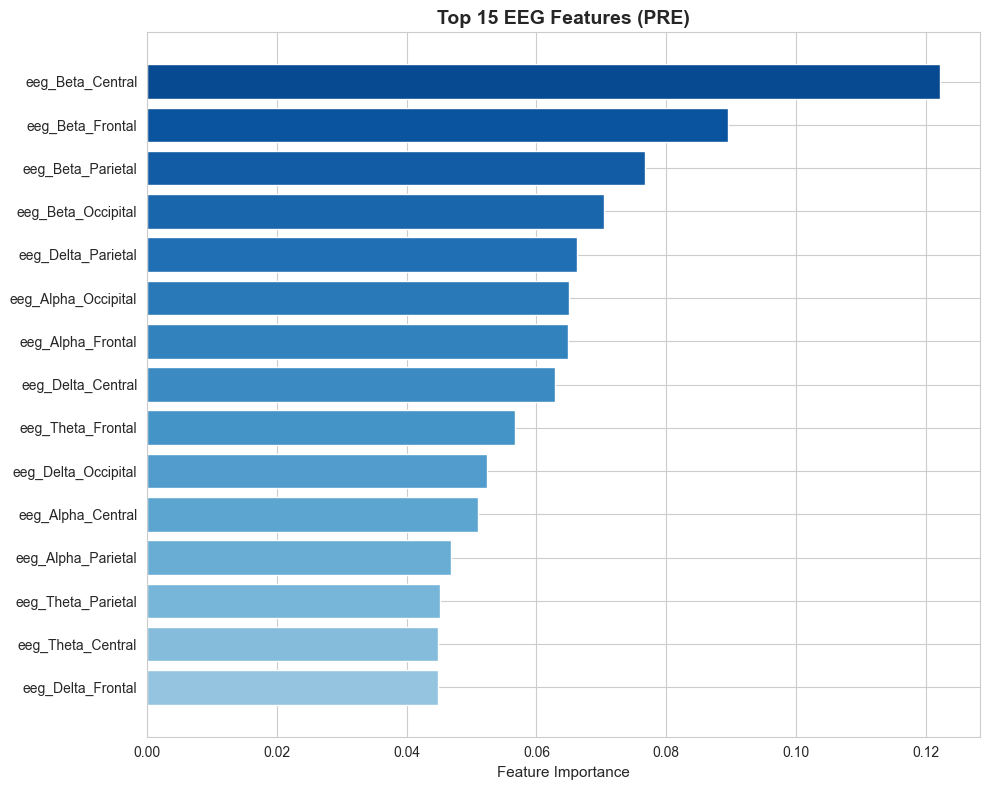

In [12]:
# Get EEG feature importances from the last trained model
if model_eeg is not None:
    eeg_importances = pd.DataFrame({
        'Feature': eeg_cols,
        'Importance': model_eeg.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n" + "="*50)
    print("EEG FEATURE IMPORTANCES")
    print("="*50)
    print(eeg_importances.to_string(index=False))
    
    # Visualize top features
    fig, ax = plt.subplots(figsize=(10, 8))
    top_n = min(15, len(eeg_importances))
    
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))
    ax.barh(range(top_n), eeg_importances['Importance'].head(top_n).values[::-1], color=colors)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(eeg_importances['Feature'].head(top_n).values[::-1])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top {top_n} EEG Features ({TIMEFRAME})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 11. Save Results

In [13]:
# Save results using shared utility
import os
output_dir = f'../../data/results/main/eeg_integration/fusion_models_eeg_{TIMEFRAME}'
os.makedirs(output_dir, exist_ok=True)

# 1. Save method comparison results
save_results(comparison_df, 
             f'{output_dir}/late_fusion_with_eeg_{TIMEFRAME}_method_comparison.csv')

# 2. Save modality weights
save_results(weights_df,
             f'{output_dir}/late_fusion_with_eeg_{TIMEFRAME}_modality_weights.csv')

# 3. Save weighted fusion summary
weighted_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Accuracy_SEM', 'F1_Score', 'F1_SEM', 'N_Subjects', 'N_Trials'],
    'Value': [
        results_weighted['accuracy_mean'],
        results_weighted['accuracy_sem'],
        results_weighted['f1_mean'],
        results_weighted['f1_sem'],
        results_weighted['n_subjects'],
        results_weighted['n_trials']
    ]
})
save_results(weighted_summary,
             f'{output_dir}/late_fusion_with_eeg_{TIMEFRAME}_weighted_fusion_summary.csv')

# 4. Save subject-level accuracies
subject_df = pd.DataFrame({
    'subject_id': list(results_weighted['subject_accs'].keys()),
    'accuracy': list(results_weighted['subject_accs'].values())
})
save_results(subject_df,
             f'{output_dir}/late_fusion_with_eeg_{TIMEFRAME}_subject_accuracies.csv')
print(f"  - {len(subject_df)} subjects, Mean accuracy: {subject_df['accuracy'].mean():.4f}")

# 5. Save EEG feature importances
if model_eeg is not None:
    save_results(eeg_importances,
                 f'{output_dir}/late_fusion_with_eeg_{TIMEFRAME}_eeg_feature_importances.csv')

print(f"\nAll results saved to: {output_dir}/")

✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_method_comparison.csv
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_modality_weights.csv
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_weighted_fusion_summary.csv
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_subject_accuracies.csv
  - 82 subjects, Mean accuracy: 0.6980
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_eeg_feature_importances.csv

All results saved to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/
